Hello world

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28856\2906857162.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


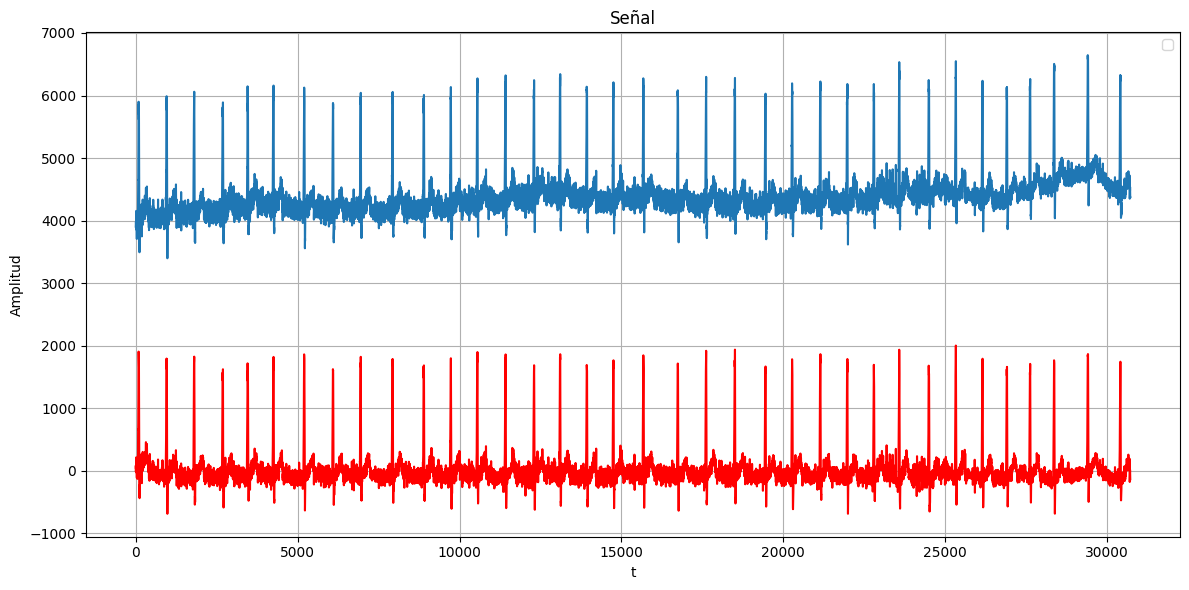

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28856\2906857162.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


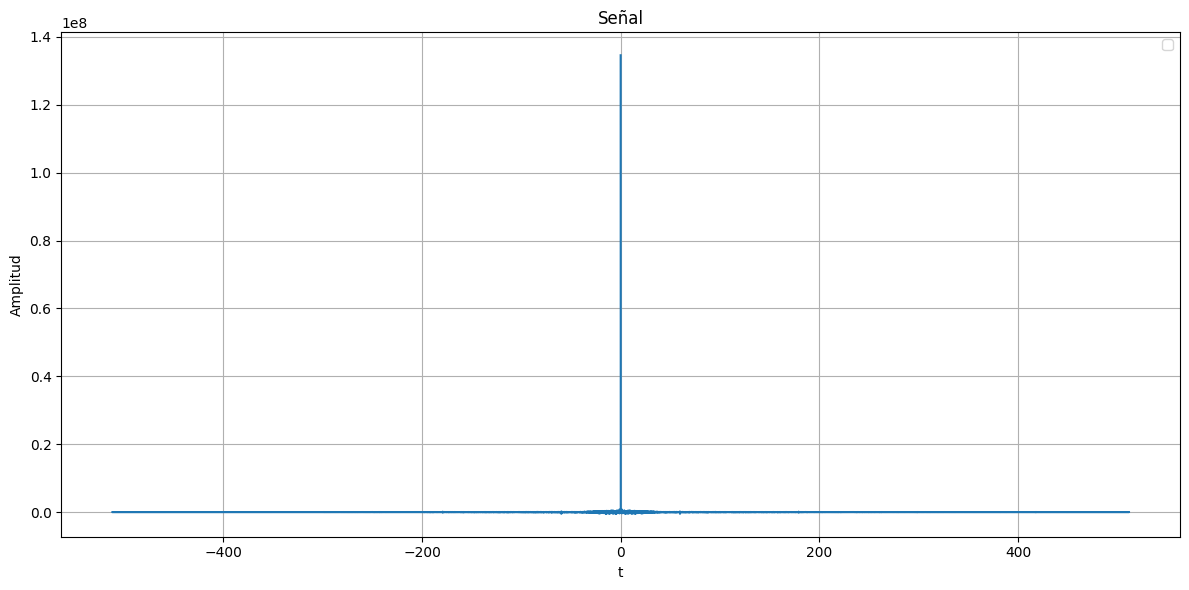

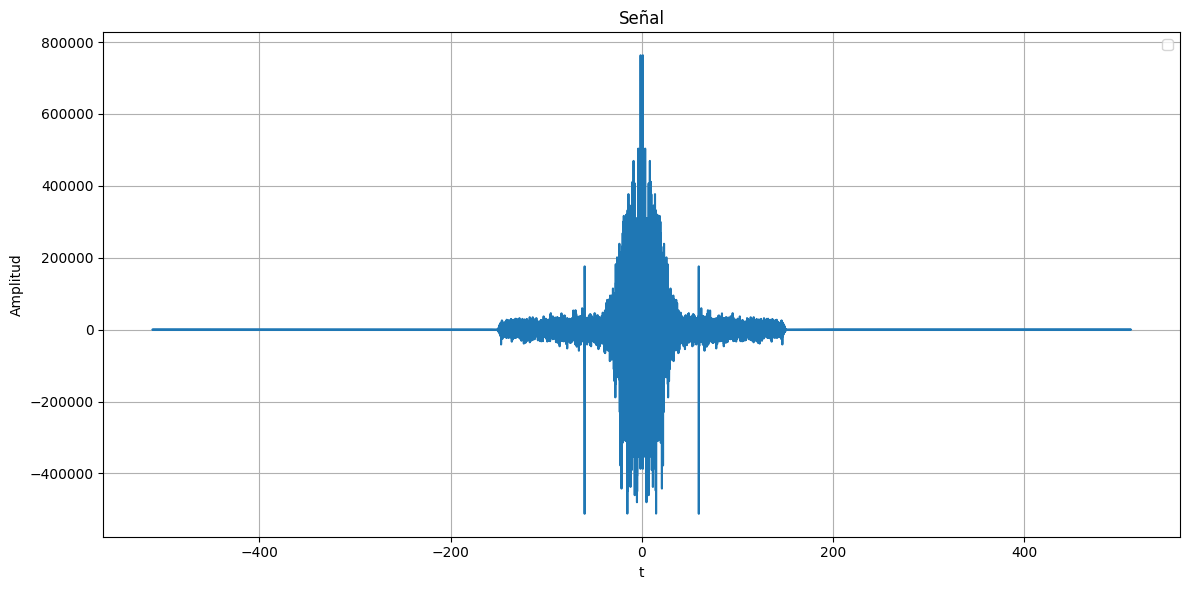

(134589600.52294922+0j)
(763140.6203140013+643149.3038885785j)


In [11]:
from scipy.stats import mannwhitneyu
#from statsmodels.tsa.stattools import adfuller
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def rms(signal):
    n = np.shape(signal)[0]
    rms = np.sqrt(1 / n * np.sum(signal ** 2))
    return rms

def graficar_solo(t, signal):
    fig, axs = plt.subplots(1, 1, figsize=(12, 6))
    axs.plot(t, signal)
    axs.set_title('Señal')
    axs.set_xlabel('t')
    axs.set_ylabel('Amplitud')
    axs.grid()
    axs.legend()

    plt.tight_layout()
    plt.show()
    return None

def graficar(t, signal, signal2):
    fig, axs = plt.subplots(1, 1, figsize=(12, 6))
    axs.plot(t, signal)
    axs.plot(t, signal2, '-r')
    axs.set_title('Señal')
    axs.set_xlabel('t')
    axs.set_ylabel('Amplitud')
    axs.grid()
    axs.legend()

    plt.tight_layout()
    plt.show()
    return None

fs = 1024 #Hz
signals = sio.loadmat(r'signals.mat') # cambiar para colab
print(signals.keys())
# 'ECG_asRecording'
# 'EMG_asRecording1'
# 'EMG_asRecording2'

#señal ecg en t
ecg = signals['ECG_asRecording']
ecg_filtrada = signals['ECG_filtered']

#Vec tiempo
vec_tiempo = np.arange(0, len(ecg[0]))

#señal ecg en freq
freqs = np.fft.fftfreq(len(ecg[0]), d=1/fs)
fft_ecg = np.fft.fft(ecg[0])
fft_ecg_filtrada = np.fft.fft(ecg_filtrada[0])

#señal emg
emg = signals['EMG_asRecording1']

graficar(vec_tiempo, ecg[0], ecg_filtrada[0])
#graficar(freqs, fft_ecg, fft_ecg_filtrada)
graficar_solo(freqs, fft_ecg)
graficar_solo(freqs, fft_ecg_filtrada)
print(np.max(fft_ecg))
print(np.max(fft_ecg_filtrada))


EXPLICACIÓN DIFERENCIAS SEÑAL NORMAL + SEÑAL FILTRADA.